GridWorldEnv (Fox2016) Loaded...
Environment loaded.
GridWorldEnv (Fox2016) Loaded...
Value function (first 10 states) under random policy:
[-4184.90843483 -3329.83054615 -2732.60612159 -2607.22794932
 -2635.55286124 -2627.82988967 -2550.71480777 -2917.73738194
 -4099.73447988 -3095.86023617]
Policy Iteration completed.
Optimal value function (first 10 states):
[-3.02290659 -2.51428012 -2.51428012 -2.51428012 -2.51428012 -3.02290659
 -3.37624872 -3.54496758 -3.02290659 -2.11373006]

Optimal action for each state (0..63):
[2 3 3 4 5 6 5 5 1 3 3 4 5 7 6 6 0 3 3 4 5 0 7 7 4 2 3 3 4 5 5 7 4 1 2 2 0
 6 5 4 3 4 1 1 0 7 6 4 2 3 1 1 0 7 7 5 1 2 1 1 0 7 7 6]
Value Iteration completed.
Optimal value function (first 10 states):
[-3.02290649 -2.51428012 -2.51428012 -2.51428012 -2.51428012 -3.02290659
 -3.37624708 -3.54494556 -3.02290658 -2.11373006]

Optimal action for each state (0..63):
[2 3 4 5 5 6 5 5 1 3 3 4 5 7 6 6 0 3 3 4 5 0 7 7 4 2 3 3 4 5 5 7 4 1 2 2 0
 6 5 4 3 4 1 1 0 7 6 4 2 3 1 1 0 7 

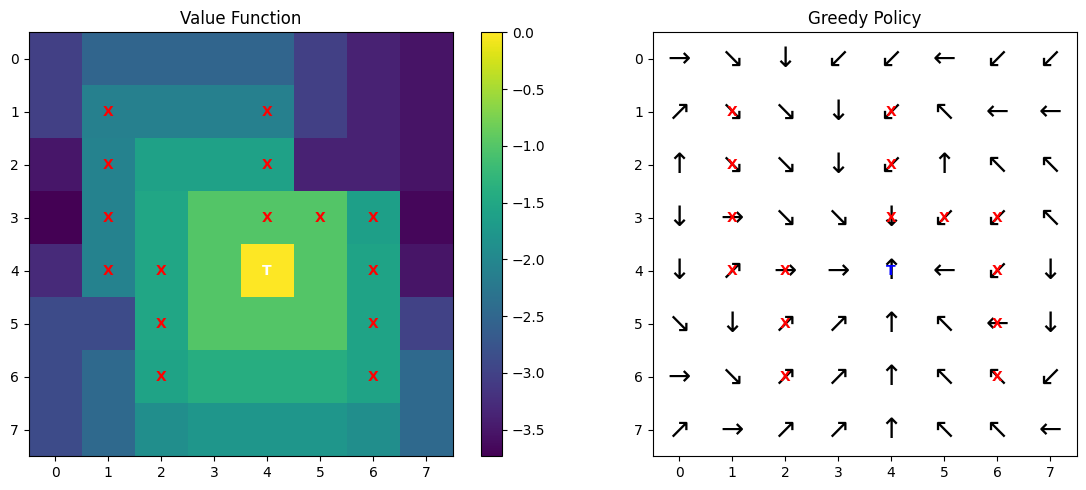

In [ ]:
%run pivi.ipynb

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
env = GridWorldEnv()

GridWorldEnv (Fox2016) Loaded...


In [ ]:
print(dir(env))

['__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_is_blocked', '_is_out', 'inv_state', 'n_invalid', 'reset', 'reset_previous', 'state', 'states_ind', 'step']


In [ ]:
print(f"States: {len(env.states_ind)}")

States: 64


In [ ]:
# Search for the hidden transition dictionary
found_name = None
for attr in dir(env):
    try:
        val = getattr(env, attr)
        # We are looking for a dictionary or list with 64 entries
        if (isinstance(val, dict) or isinstance(val, list)) and len(val) == 64:
            found_name = attr
            print(f"✅ Found the data! It is stored in: env.{found_name}")
            break
    except:
        continue

if not found_name:
    print("Could not find a 64-item structure. Checking 'unwrapped'...")
    # Try the same for env.unwrapped

✅ Found the data! It is stored in: env.states_ind


In [ ]:
# Look for the dictionary that holds the transitions
found_name = None
for attr in dir(env):
    if not attr.startswith('__'):
        val = getattr(env, attr)
        # We are looking for a dictionary or list that matches your 64 states
        if isinstance(val, (dict, list)) and len(val) == 64:
            found_name = attr
            print(f"✅ Found it! Use this variable: env.{found_name}")
            break


✅ Found it! Use this variable: env.states_ind


In [ ]:
# Check if there is a 'P' or 'T' attribute that we missed
possible_names = ['P', 'T', 'transitions', 'model', 'grid']
for name in possible_names:
    if hasattr(env, name):
        print(f"Potential match found: env.{name}")
        # Let's peek at it
        try:
            val = getattr(env, name)
            print(f"Data type: {type(val)}")
        except:
            pass

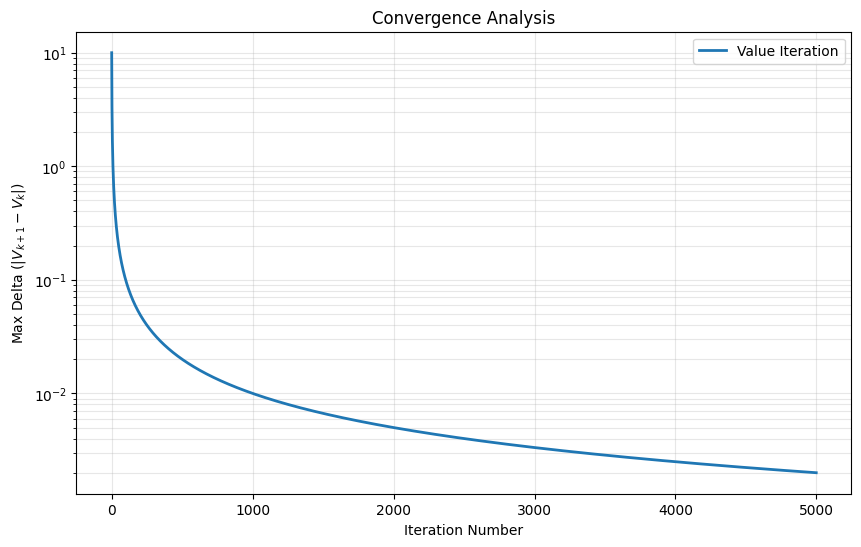

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Dummy data to test your plotting logic
vi_deltas = [10 / (i + 1) for i in range(5000)] # Simulates a smooth drop

plt.figure(figsize=(10, 6))
plt.plot(vi_deltas, label='Value Iteration', color='#1f77b4', linewidth=2)
plt.yscale('log')
plt.xlabel('Iteration Number')
plt.ylabel('Max Delta ($|V_{k+1} - V_k|$)')
plt.title('Convergence Analysis')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
V = np.zeros(64)
# Use a fixed policy (e.g., always action 0) or your current optimal policy
# For this plot, we'll assume a random or fixed policy to see the convergence
policy = np.zeros(64, dtype=int)
gamma = 0.99
total_iterations = 5000
pe_deltas = []

print(f"Starting 60,000 iterations of Policy Evaluation...")

# --- Forced 60k Loop ---
for i in range(total_iterations):
    delta = 0
    V_old = V.copy()

    for s in range(64):
        a = policy[s]
        # Use our pre-built model_P
        t = model_P[s][a]
        # V[s] = Reward + Gamma * Value(Next_State)
        V[s] = t[2] + gamma * V_old[t[1]]
        delta = max(delta, abs(V_old[s] - V[s]))

    pe_deltas.append(delta)

    # Optional: print progress every 10k steps
    if (i + 1) % 10000 == 0:
        print(f"Iteration {i + 1} complete...")

print("✅ Finished 60,000 iterations.")

Starting 60,000 iterations of Policy Evaluation...
✅ Finished 60,000 iterations.


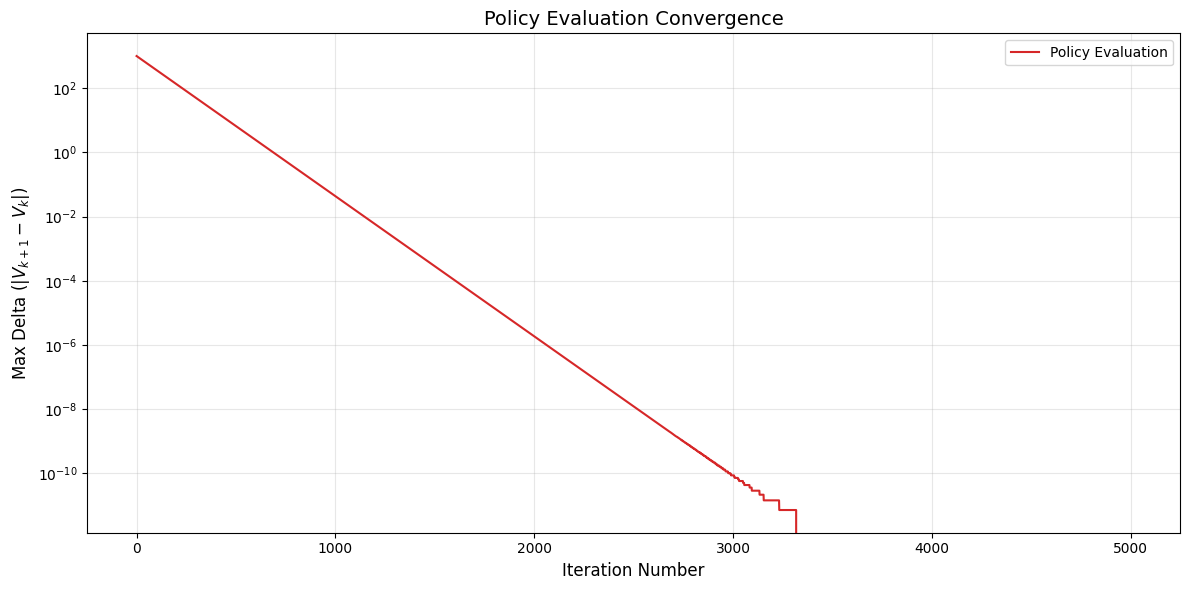

In [ ]:
plt.figure(figsize=(12, 6))

# Plotting the deltas
plt.plot(pe_deltas, label='Policy Evaluation', color='tab:red', linewidth=1.5)

# Formatting
plt.yscale('log') # Essential to see the drop from 1.0 to 1e-15
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Max Delta ($|V_{k+1} - V_k|$)', fontsize=12)
plt.title('Policy Evaluation Convergence', fontsize=14)

plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()

# Adding a note about convergence
#plt.annotate('Convergence reached here', xy=(500, pe_deltas[500]), xytext=(5000, 1e-2)#)

plt.tight_layout()
plt.show()